In [34]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, ResNet50, InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [35]:
train_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Train"
val_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/val"
test_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Test"

In [37]:
# Set paths
base_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET"  # Replace with your dataset path
train_dir = os.path.join(base_dir, "Train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "Test")
model_save_path = "saved_models"
os.makedirs(model_save_path, exist_ok=True)

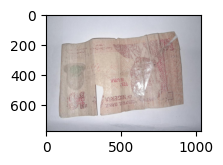

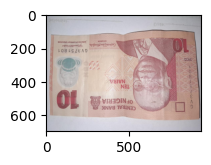

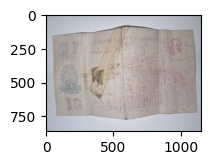

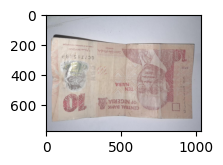

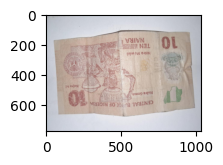

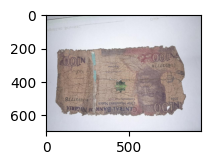

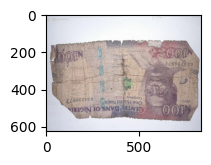

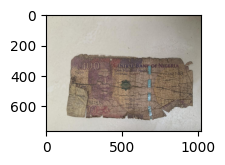

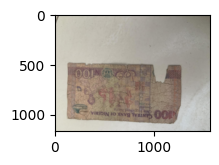

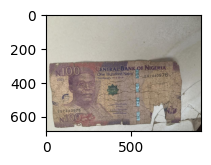

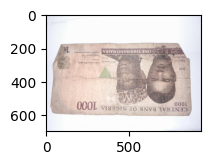

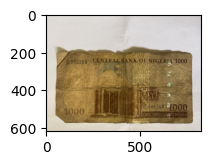

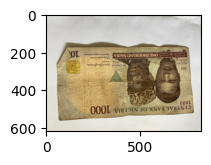

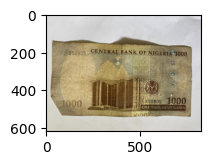

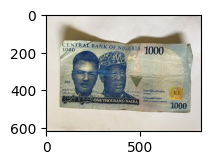

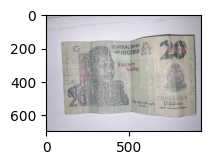

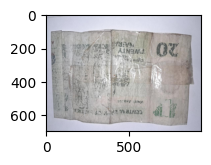

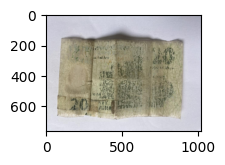

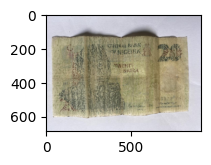

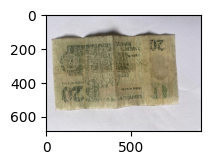

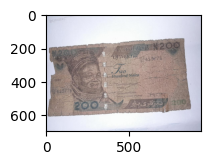

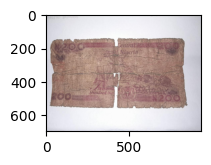

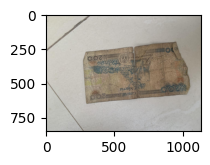

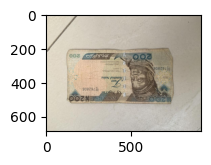

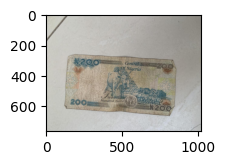

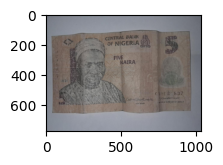

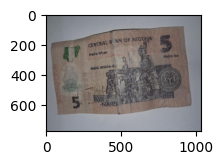

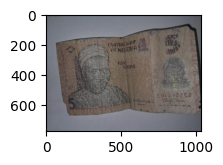

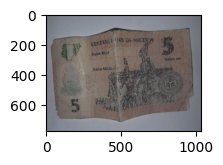

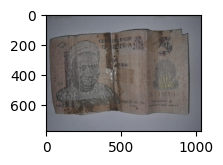

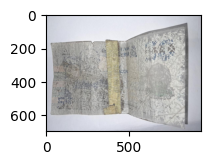

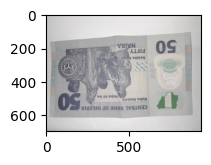

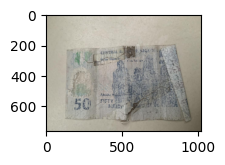

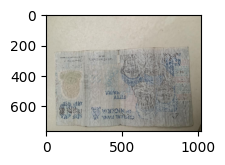

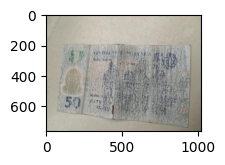

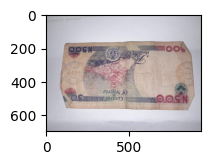

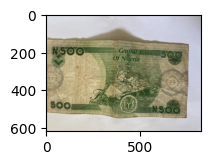

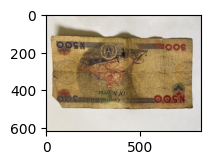

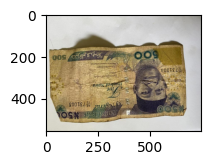

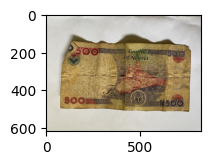

In [38]:
for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    image_count = 0
    for file in os.listdir(folder_path):
        image_path = os.path.join(folder_path,file)
        plt.figure(figsize=(2, 2))
        plt.imshow(plt.imread(image_path))
        plt.show()
        image_count += 1
        if image_count == 5:
            break

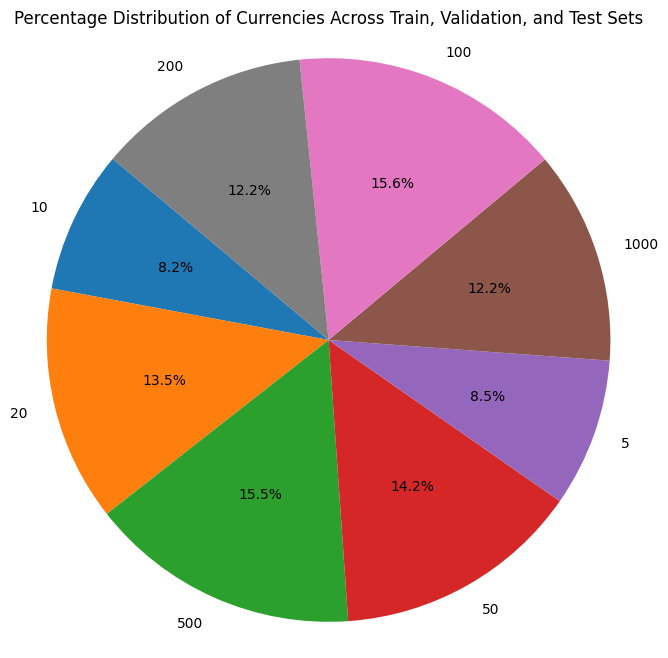

In [39]:
import os
import matplotlib.pyplot as plt

def count_images_per_class(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            counts[class_name] = image_count
    return counts

# Paths
train_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Train"
val_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/val"
test_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Test"

# Count images
train_counts = count_images_per_class(train_dir)
val_counts = count_images_per_class(val_dir)
test_counts = count_images_per_class(test_dir)

# Combine all counts
total_counts = {}
for label in set(train_counts) | set(val_counts) | set(test_counts):
    total_counts[label] = train_counts.get(label, 0) + val_counts.get(label, 0) + test_counts.get(label, 0)

# Plot pie chart
labels = list(total_counts.keys())
sizes = list(total_counts.values())

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Percentage Distribution of Currencies Across Train, Validation, and Test Sets')
plt.axis('equal')
plt.show()


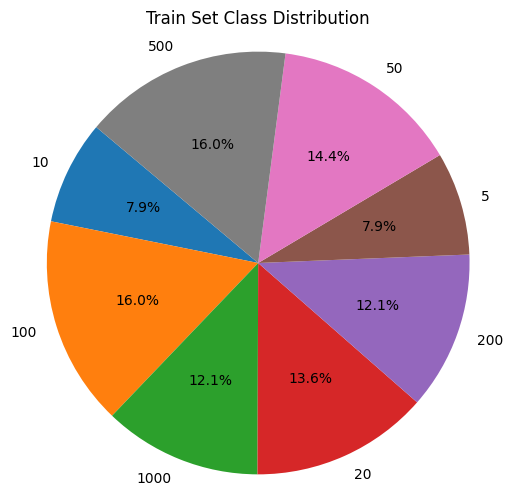

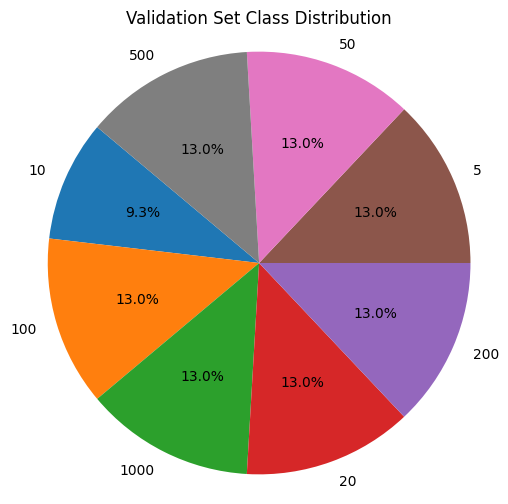

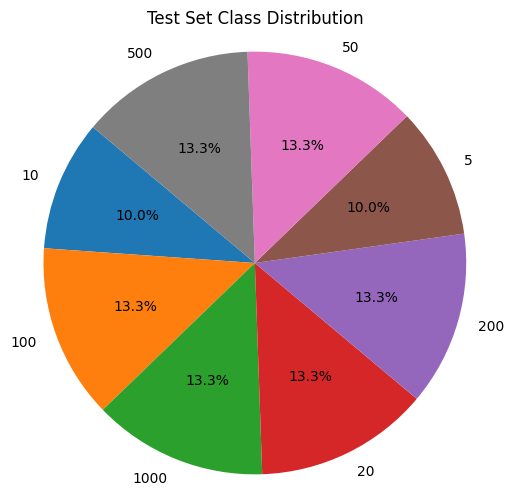

In [17]:
import os
import matplotlib.pyplot as plt

def count_images_per_class(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            counts[class_name] = image_count
    return counts

# Paths
train_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Train"
val_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/val"
test_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Test"

# Count images
train_counts = count_images_per_class(train_dir)
val_counts = count_images_per_class(val_dir)
test_counts = count_images_per_class(test_dir)

# Plot function for pie chart
def plot_pie_chart(data_dict, title):
    labels = list(data_dict.keys())
    sizes = list(data_dict.values())
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.axis('equal')
    plt.show()

# Pie charts for each dataset
plot_pie_chart(train_counts, 'Train Set Class Distribution')
plot_pie_chart(val_counts, 'Validation Set Class Distribution')
plot_pie_chart(test_counts, 'Test Set Class Distribution')


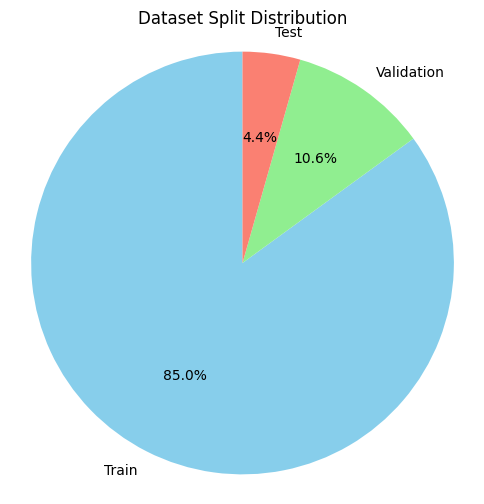

In [40]:
import os
import matplotlib.pyplot as plt

def count_total_images(directory):
    total = 0
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            total += len(os.listdir(class_path))
    return total

# Directories
train_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Train"
val_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/val"
test_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Test"

# Count total images in each set
train_total = count_total_images(train_dir)
val_total = count_total_images(val_dir)
test_total = count_total_images(test_dir)

# Pie chart
labels = ['Train', 'Validation', 'Test']
sizes = [train_total, val_total, test_total]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'salmon'], startangle=90)
plt.title('Dataset Split Distribution')
plt.axis('equal')
plt.show()


In [41]:
img_size = (224, 224)
batch_size = 32
epochs = 20

In [42]:
# Data generators
basic_aug = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2,
                               height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
                               horizontal_flip=True)

In [47]:
def load_data(preprocess_fn=None):
    train_gen = basic_aug.flow_from_directory(train_dir, target_size=img_size, class_mode='categorical', batch_size=batch_size)
    val_gen = basic_aug.flow_from_directory(val_dir, target_size=img_size, class_mode='categorical', batch_size=batch_size)
    test_gen = basic_aug.flow_from_directory(test_dir, target_size=img_size, class_mode='categorical', batch_size=1, shuffle=False)
    return train_gen, val_gen, test_gen

In [14]:
# Build CNN
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [15]:
# Build transfer learning model
def build_transfer_model(base_model, num_classes):
    base_model.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [16]:
models = {
    "Basic_CNN": build_cnn((224, 224, 3), 8),
    "VGG19": build_transfer_model(VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), 8),
    "ResNet50": build_transfer_model(ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), 8),
    "InceptionV3": build_transfer_model(InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), 8)
}

In [17]:
histories = {}

for name, model in models.items():
    print(f"🚀 Training {name}")
    train_gen, val_gen, test_gen = load_data()
    model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs)
    model.save(os.path.join(model_save_path, f"{name}_naira_model.h5"))
    histories[name] = history
    print(f"✅ Finished training {name}")

🚀 Training Basic_CNN
Found 1736 images belonging to 8 classes.
Found 216 images belonging to 8 classes.
Found 90 images belonging to 8 classes.
Epoch 1/20
55/55 [==============================] - 138s 2s/step - loss: 2.0640 - accuracy: 0.1872 - val_loss: 1.9477 - val_accuracy: 0.2593
Epoch 2/20
55/55 [==============================] - 135s 2s/step - loss: 1.8749 - accuracy: 0.2535 - val_loss: 1.8769 - val_accuracy: 0.2593
Epoch 3/20
55/55 [==============================] - 131s 2s/step - loss: 1.7869 - accuracy: 0.2990 - val_loss: 1.7991 - val_accuracy: 0.2639
Epoch 4/20
55/55 [==============================] - 146s 3s/step - loss: 1.7206 - accuracy: 0.3122 - val_loss: 1.7683 - val_accuracy: 0.3380
Epoch 5/20
55/55 [==============================] - 135s 2s/step - loss: 1.6894 - accuracy: 0.3393 - val_loss: 1.6778 - val_accuracy: 0.4028
Epoch 6/20
55/55 [==============================] - 131s 2s/step - loss: 1.6136 - accuracy: 0.3733 - val_loss: 1.5951 - val_accuracy: 0.4352
Epoch 7/20

C:\Users\GOIT\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Finished training Basic_CNN
🚀 Training VGG19
Found 1736 images belonging to 8 classes.
Found 216 images belonging to 8 classes.
Found 90 images belonging to 8 classes.
Epoch 1/20
55/55 [==============================] - 957s 17s/step - loss: 2.3355 - accuracy: 0.1354 - val_loss: 2.0896 - val_accuracy: 0.1759
Epoch 2/20
55/55 [==============================] - 951s 17s/step - loss: 2.1576 - accuracy: 0.1584 - val_loss: 2.0424 - val_accuracy: 0.2130
Epoch 3/20
55/55 [==============================] - 952s 17s/step - loss: 2.0966 - accuracy: 0.1803 - val_loss: 2.0014 - val_accuracy: 0.2222
Epoch 4/20
55/55 [==============================] - 943s 17s/step - loss: 2.0285 - accuracy: 0.2126 - val_loss: 1.9771 - val_accuracy: 0.2685
Epoch 5/20
55/55 [==============================] - 949s 17s/step - loss: 1.9770 - accuracy: 0.2529 - val_loss: 1.9417 - val_accuracy: 0.3056
Epoch 6/20
55/55 [==============================] - 948s 17s/step - loss: 1.9305 - accuracy: 0.2725 - val_loss: 1.8981 -

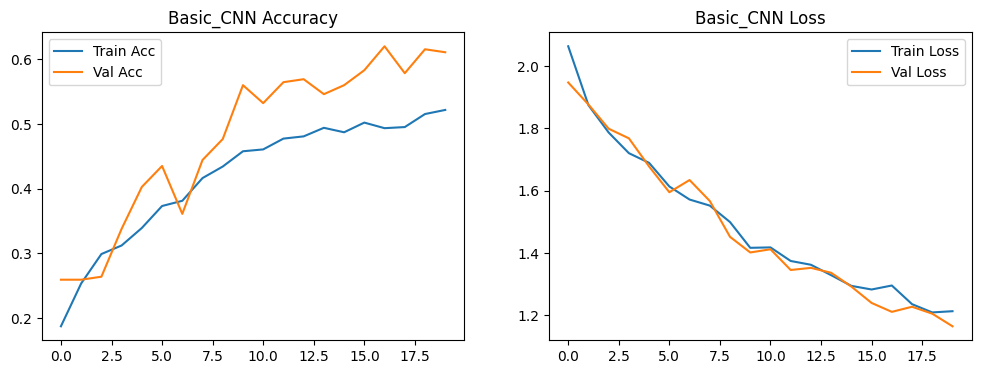

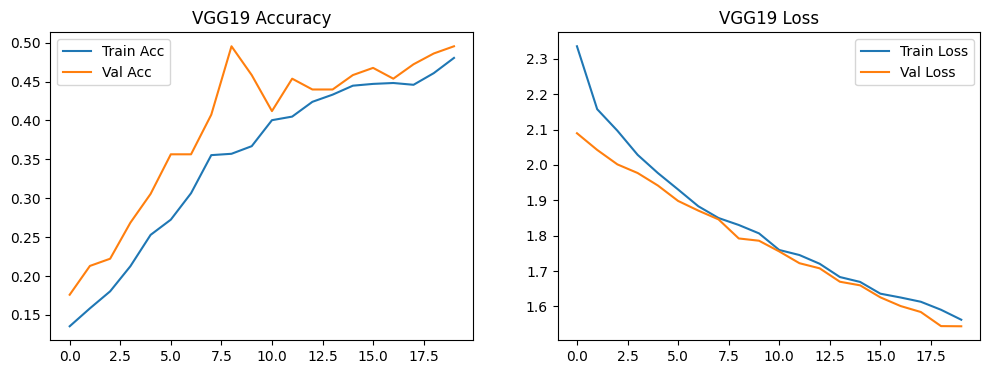

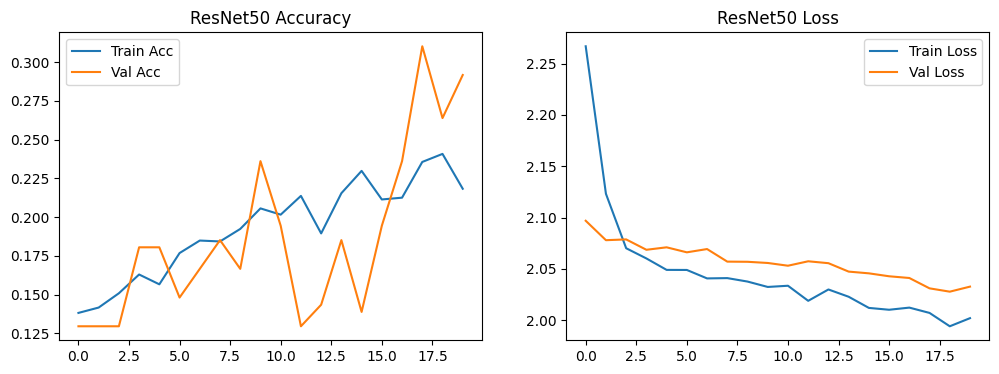

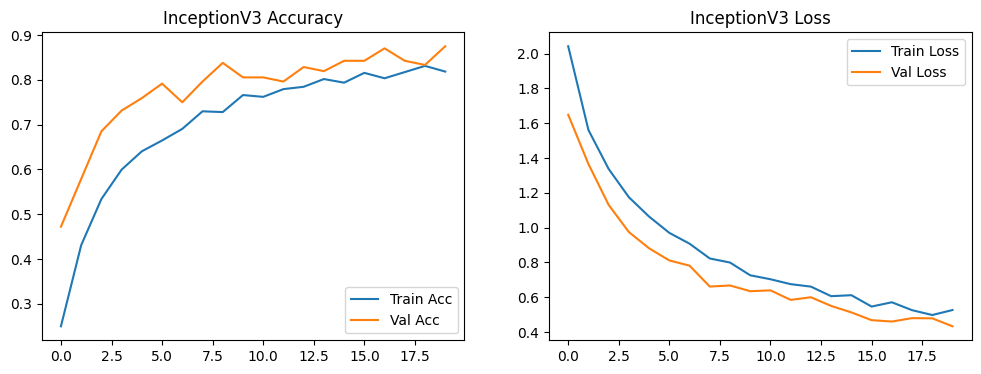

In [18]:
# Plot accuracy and loss
for name, history in histories.items():
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

Found 90 images belonging to 8 classes.
3/3 [==============================] - 5s 1s/step


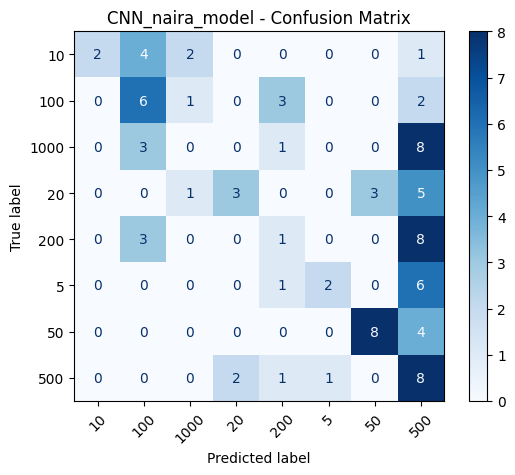

3/3 [==============================] - 142s 45s/step


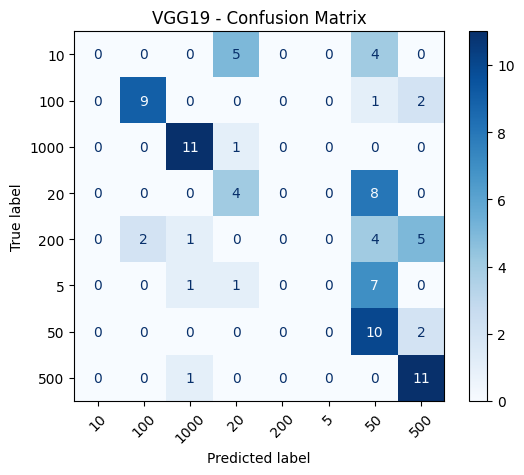

3/3 [==============================] - 49s 13s/step


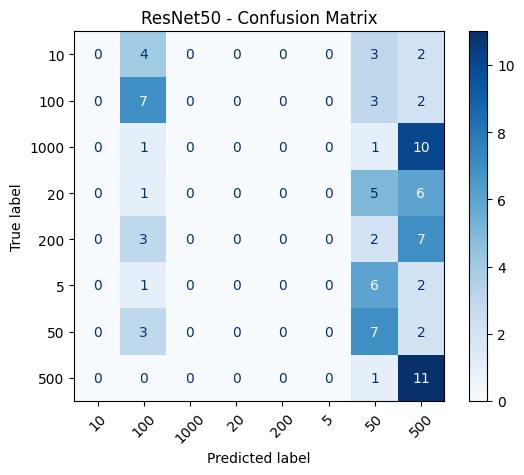

3/3 [==============================] - 37s 7s/step


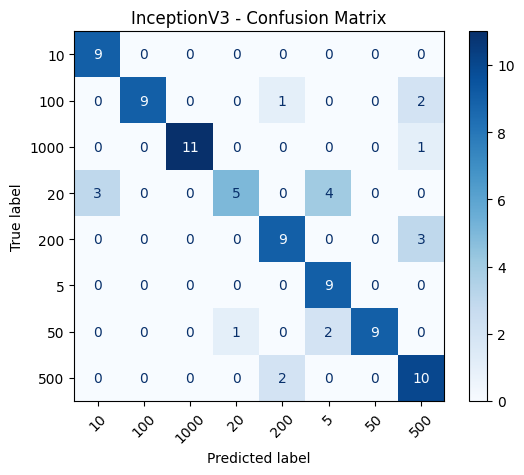

In [15]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Test data generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Function to evaluate and plot confusion matrix
def plot_confusion_matrix(model_path, model_name):
    model = load_model(model_path)
    predictions = model.predict(test_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes
    labels = list(test_generator.class_indices.keys())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()
    

# Run for each model
plot_confusion_matrix("Basic_CNN_naira_model.h5", "CNN_naira_model")
plot_confusion_matrix("VGG19_naira_model.h5", "VGG19")
plot_confusion_matrix("ResNet50_naira_model.h5", "ResNet50")
plot_confusion_matrix("InceptionV3_naira_model.h5", "InceptionV3")


In [24]:
# Save model history
histories[name] = history

    # Save the model
model.save(f"{name}_naira_classifier_augmented.h5")

    # Predict on test data
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test accuracy for {name}: {test_acc:.4f}")

90/90 [==============================] - 12s 130ms/step - loss: 0.7257 - accuracy: 0.7556
✅ Test accuracy for InceptionV3: 0.7556


In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the test data generator (no augmentation, just rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

# Set the test directory path
test_dir = "C:/Users/GOIT/Desktop/NAIRA DATASET/Test"

# Create the test generator
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)



Found 90 images belonging to 8 classes.


In [54]:
from tensorflow.keras.models import load_model

model = load_model("Basic_CNN_naira_model.h5")
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test accuracy: {test_acc:.4f}")


3/3 [==============================] - 3s 716ms/step - loss: 2.2178 - accuracy: 0.3333
✅ Test accuracy: 0.3333


In [55]:
from tensorflow.keras.models import load_model

model = load_model("VGG19_naira_model.h5")
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test accuracy: {test_acc:.4f}")


3/3 [==============================] - 34s 11s/step - loss: 1.5588 - accuracy: 0.5000
✅ Test accuracy: 0.5000


In [57]:
from tensorflow.keras.models import load_model

model = load_model("ResNet50_naira_model.h5")
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test accuracy: {test_acc:.4f}")


3/3 [==============================] - 15s 4s/step - loss: 2.0326 - accuracy: 0.2778
✅ Test accuracy: 0.2778


In [58]:
from tensorflow.keras.models import load_model

model = load_model("InceptionV3_naira_model.h5")
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test accuracy: {test_acc:.4f}")

3/3 [==============================] - 10s 2s/step - loss: 0.5778 - accuracy: 0.7889
✅ Test accuracy: 0.7889
